# 05 · Temporal splitting cannot repair a future-leaking feature

## Goal
Use a known synthetic panel to distinguish useful, redundant, spurious and invalid information.

**Status:** worked example prepared by Codex; learner understanding unassessed. No API calls.

## Setup
Run top to bottom. All examples are synthetic unless explicitly labelled as public evidence.

In [1]:
from pathlib import Path
import sys, json, tempfile
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'signal_lab').is_dir(), 'Run from the companion root or notebooks directory'
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (8, 4.2), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})


## Steps

### 1. Generate and inspect the panel
180 dates × eight invented assets. Common shocks create cross-sectional dependence. A toy 0.004 coefficient defines the useful signal; it is not estimated economic truth.

In [2]:
from signal_lab.quant import panel,evaluate_panel,incremental_mse,assert_available
f=panel(seed=7); result=evaluate_panel(f)
result.round(7)

,feature,split,mse,correlation,valid
0,useful,development,0.000259,0.203026,True
1,useful,visible_transfer,0.000261,0.183978,True
2,redundant,development,0.000259,0.203026,True
3,redundant,visible_transfer,0.000261,0.183978,True
4,spurious,development,0.000004,0.992464,False
5,spurious,visible_transfer,0.000645,-0.013463,False
6,leaked,development,0.000000,1.000000,False
7,leaked,visible_transfer,0.000000,1.000000,False


### 2. Compare prediction errors
The spurious predictor uses outcomes in its development construction. The leaked predictor equals the target. Both are invalid; perfect error is not a pass.

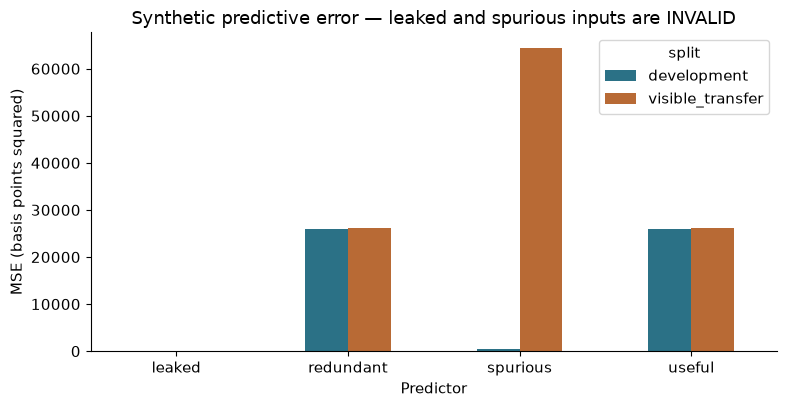

In [3]:
pivot=result.pivot(index='feature',columns='split',values='mse')*1e8
ax=pivot.plot.bar(color=['#2b7186','#b86a35'])
ax.set(title='Synthetic predictive error — leaked and spurious inputs are INVALID',ylabel='MSE (basis points squared)',xlabel='Predictor')
plt.xticks(rotation=0);plt.tight_layout();plt.show()

### 3. Check incremental prediction and timestamps

In [4]:
incremental_mse(f)

{'incumbent': 0.00026078715865487446, 'plus_redundant': 0.00026078715865487446}

In [5]:
future=f['available_at']+pd.Timedelta(days=1)
try:
    assert_available(future,f['decision_at'])
except ValueError as error:
    print('Expected rejection:',error)

Expected rejection: Missing or future information at decision time


Metadata checks catch declared late arrivals. They cannot detect a lied-about timestamp or contamination inside model weights. Provenance is part of the research design, not just a parser check.

## Checks
Train/test rows are split by date; duplicate information gives no incremental least-squares gain. No naive independent-row significance or real-return inference is reported.

## Next Steps
Optional: explain why a leaked feature can succeed on the later half. Read the Baker bridge before designing any historical LLM signal test.

**Low energy:** stop here. The checkpoint is optional; reading the worked output does not update mastery.